In [1]:
#declarer le drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports et configuration

In [2]:
# Imports généraux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Standardisation et PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score

# Autres outils
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


### Chargement des données

In [3]:
Poulet = pd.read_csv( '/content/drive/My Drive/Colab Notebooks/P11_OPC/merge_final.csv')

In [4]:
Poulet.columns

Index(['Code Élément', 'Élément', 'Valeur_dali', 'Description du Symbole',
       'Valeur_pop', 'viande_conso', 'country', 'production_tonnes', 'pib',
       'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
       'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'],
      dtype='object')

In [5]:


Poulet.head()


,Code Élément,Élément,Valeur_dali,Description du Symbole,Valeur_pop,viande_conso,country,production_tonnes,pib,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,5511,Production,28.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,5611,Importations - Quantité,29.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,5072,Variation de stock,0.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,5301,Disponibilité intérieure,57.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,5123,Pertes,2.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


In [6]:
Poulet['Élément'].unique()


array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Disponibilité intérieure', 'Pertes', 'Résidus', 'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Exportations - Quantité', 'Traitement',
       'Alimentation pour touristes',
       'Autres utilisations (non alimentaire)'], dtype=object)

## Analyse descriptive & histogrammes

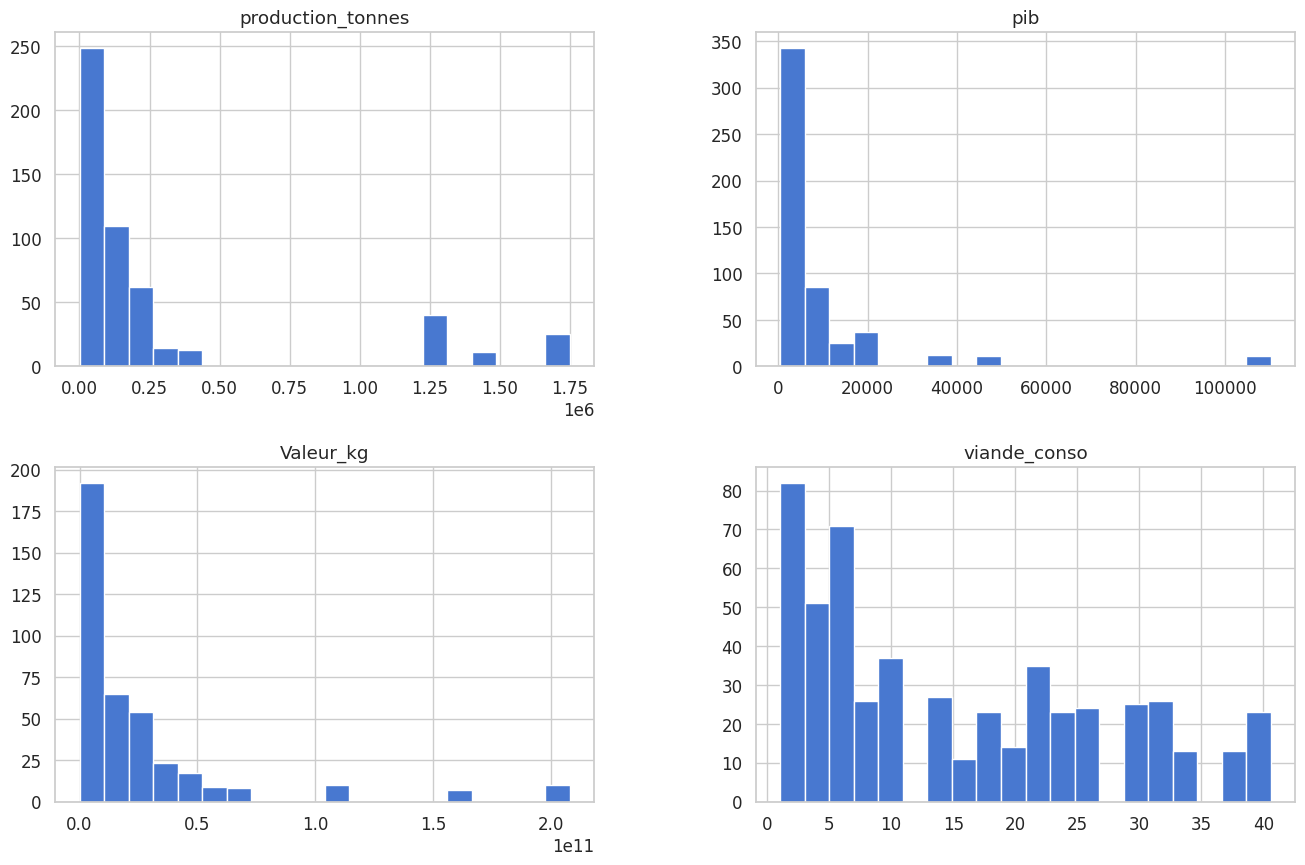

In [7]:

Poulet.describe()

# Histogrammes col num

num_cols = ['production_tonnes', 'pib', 'Valeur_kg', 'viande_conso']
Poulet[num_cols].hist(figsize=(16,10), bins=20)
plt.show()




## Matrice de corrélation en triangle supérieur avec valeurs

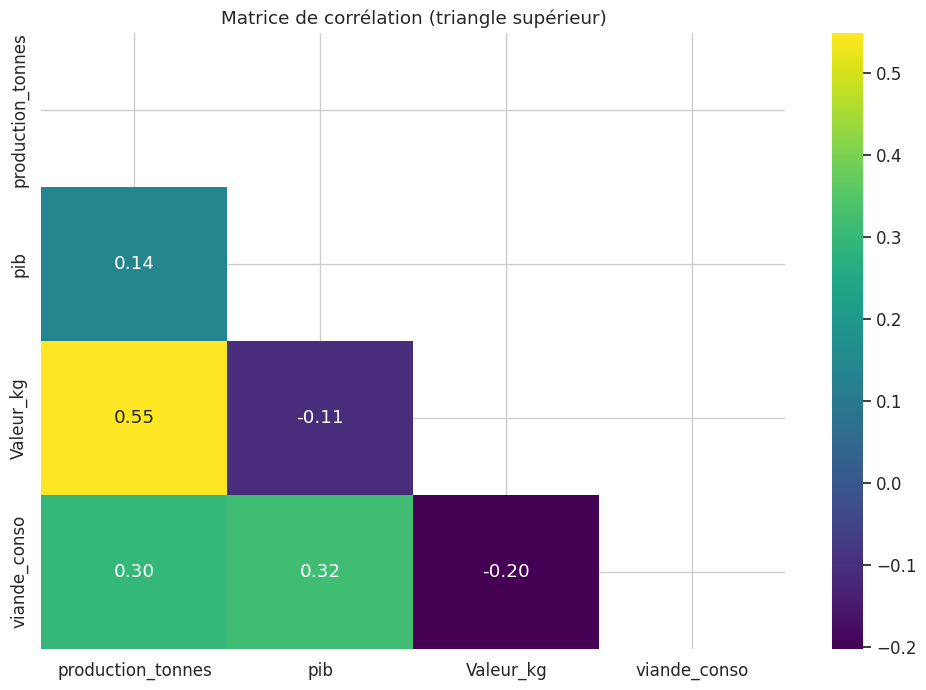

In [8]:
# Calcul de la corrélation
corr = Poulet[num_cols].corr()

# Masque triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, mask=mask, annot=True, cmap='viridis', fmt=".2f")
plt.title("Matrice de corrélation (triangle supérieur)")
plt.show()




## Standardisation et PCA

In [9]:
print(Poulet.dtypes)


Code Élément                int64
Élément                    object
Valeur_dali               float64
Description du Symbole     object
Valeur_pop                float64
viande_conso              float64
country                    object
production_tonnes         float64
pib                       float64
Voice_Accountability      float64
Political_Stability       float64
Gov_Effectiveness         float64
Reg_Quality               float64
Rule_of_Law               float64
Control_Corruption        float64
Valeur_kg                 float64
dtype: object


In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

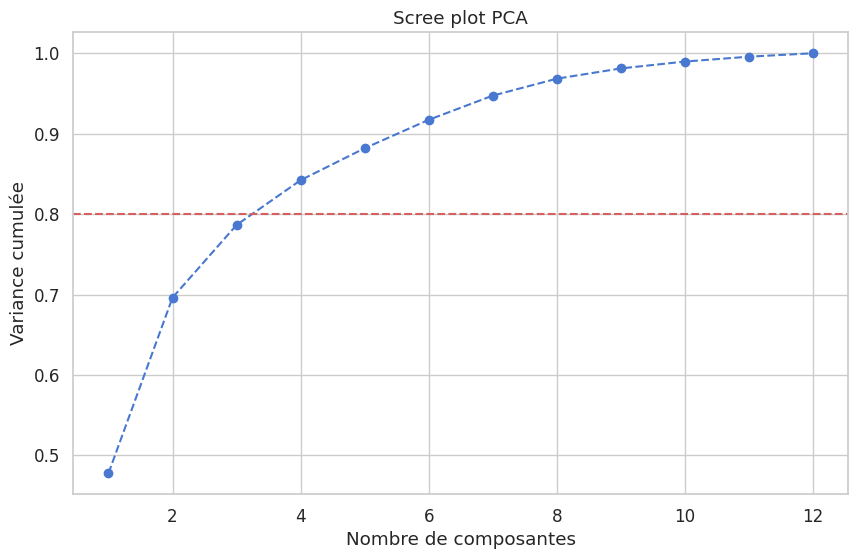

Nombre de composantes retenues : 4


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-3.417583,-0.219862,-0.404751,0.174384,0.649330,0.405729,0.036905,0.028655,-0.119127,-0.122522,-0.081456,0.217142
1,-3.417406,-0.218496,-0.403121,0.177433,0.649671,0.405745,0.037119,0.028856,-0.118680,-0.122638,-0.081450,0.217064
2,-3.422540,-0.258100,-0.450376,0.088998,0.639773,0.405279,0.030917,0.023028,-0.131654,-0.119274,-0.081622,0.219317
3,-3.412449,-0.180257,-0.357496,0.262819,0.659227,0.406194,0.043107,0.034482,-0.106153,-0.125887,-0.081285,0.214889
4,-3.422186,-0.255369,-0.447117,0.095097,0.640456,0.405311,0.031345,0.023430,-0.130760,-0.119506,-0.081610,0.219162


In [11]:
# Colonnes numériques pour l'ACP
cols_acp_exist = [
    'Valeur_dali', 'Valeur_pop', 'viande_conso', 'production_tonnes', 'pib',
    'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
    'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'
]

# Sélection des données
X = Poulet[cols_acp_exist].apply(pd.to_numeric, errors='coerce')

# Imputation des NaN par la moyenne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Scree plot
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_var)+1), cum_var, marker='o', linestyle='--')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.title('Scree plot PCA')
plt.grid(True)
plt.show()

# Nombre de composantes retenues
n_comp = np.argmax(cum_var >= 0.8) + 1
print(f"Nombre de composantes retenues : {n_comp}")

# Scores PCA
scores = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

scores.head()


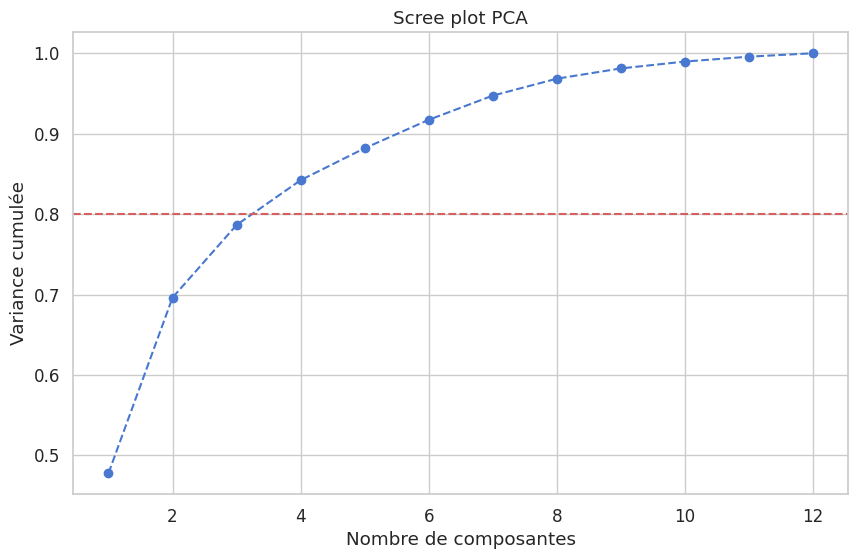

Nombre de composantes retenues : 4


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-3.417583,-0.219862,-0.404751,0.174384,0.649330,0.405729,0.036905,0.028655,-0.119127,-0.122522,-0.081456,0.217142
1,-3.417406,-0.218496,-0.403121,0.177433,0.649671,0.405745,0.037119,0.028856,-0.118680,-0.122638,-0.081450,0.217064
2,-3.422540,-0.258100,-0.450376,0.088998,0.639773,0.405279,0.030917,0.023028,-0.131654,-0.119274,-0.081622,0.219317
3,-3.412449,-0.180257,-0.357496,0.262819,0.659227,0.406194,0.043107,0.034482,-0.106153,-0.125887,-0.081285,0.214889
4,-3.422186,-0.255369,-0.447117,0.095097,0.640456,0.405311,0.031345,0.023430,-0.130760,-0.119506,-0.081610,0.219162


In [12]:


# Colonnes numériques pour l'ACP
cols_acp_exist = ['Valeur_dali', 'Valeur_pop', 'viande_conso', 'production_tonnes', 'pib',
                  'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
                  'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg']

# Sélection des données
X = Poulet[cols_acp_exist].apply(pd.to_numeric, errors='coerce')

#Imputation des NaN par la moyenne
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardisation
X_scaled = StandardScaler().fit_transform(X_imputed)

# ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

#Variance expliquée
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Scree plot
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_var)+1), cum_var, marker='o', linestyle='--')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.title('Scree plot PCA')
plt.show()

# Nombre de composantes retenues pour cum_var >= 0.8
n_comp = np.argmax(cum_var >= 0.8) + 1
print(f"Nombre de composantes retenues : {n_comp}")

#Scores PCA
scores = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(cols_acp_exist))])
scores.head()


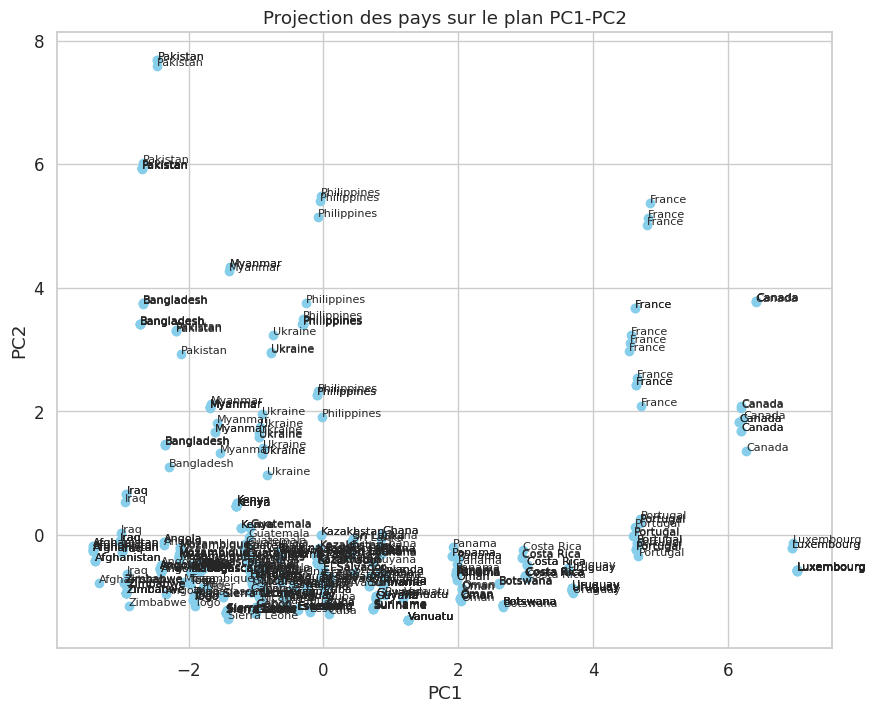

In [53]:
plt.figure(figsize=(10,8))
plt.scatter(scores['PC1'], scores['PC2'], c='skyblue')
for i, country in enumerate(Poulet['country']):
    plt.text(scores['PC1'][i], scores['PC2'][i], country, fontsize=8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection des pays sur le plan PC1-PC2')
plt.grid(True)
plt.show()


## Cercle des corrélations

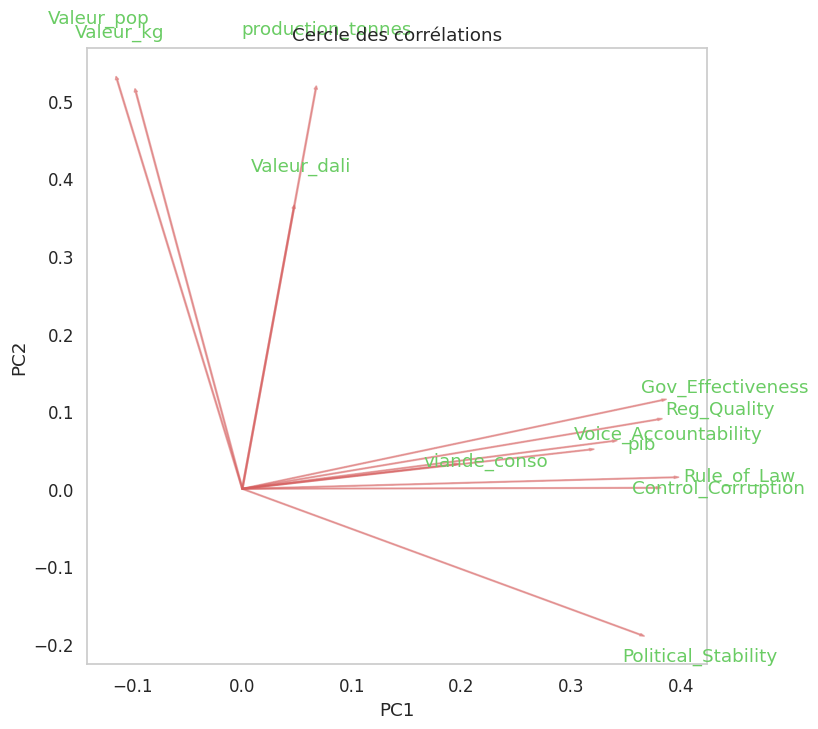

In [13]:
loadings = pca.components_.T[:, :n_comp]

plt.figure(figsize=(8,8))
for i, var in enumerate(cols_acp_exist):
    plt.arrow(0, 0, loadings[i,0], loadings[i,1], color='r', alpha=0.5)
    plt.text(loadings[i,0]*1.15, loadings[i,1]*1.15, var, color='g', ha='center', va='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("Cercle des corrélations")
plt.grid()
plt.show()


## Projection des pays : PC1 vs PC2

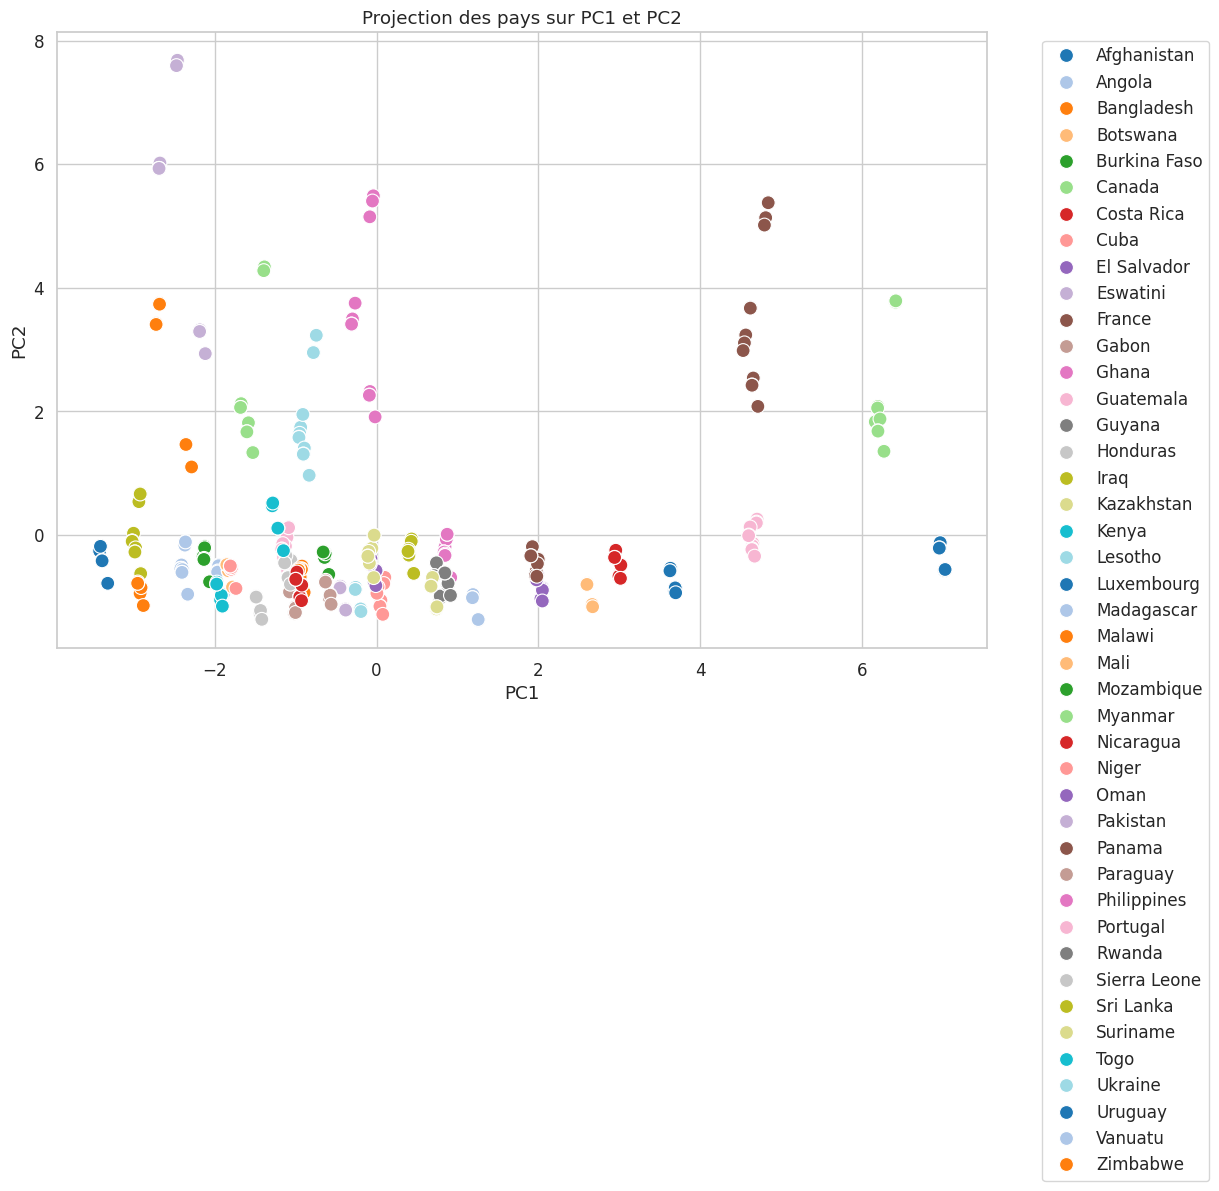

In [52]:
scores_df = pd.DataFrame(X_pca[:,:n_comp], columns=[f'PC{i+1}' for i in range(n_comp)])
scores_df['country'] = Poulet['country']

plt.figure(figsize=(12,8))
sns.scatterplot(data=scores_df, x='PC1', y='PC2', hue='country', palette='tab20', s=100)
plt.title("Projection des pays sur PC1 et PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()


## Clustering hiérarchique :CAH

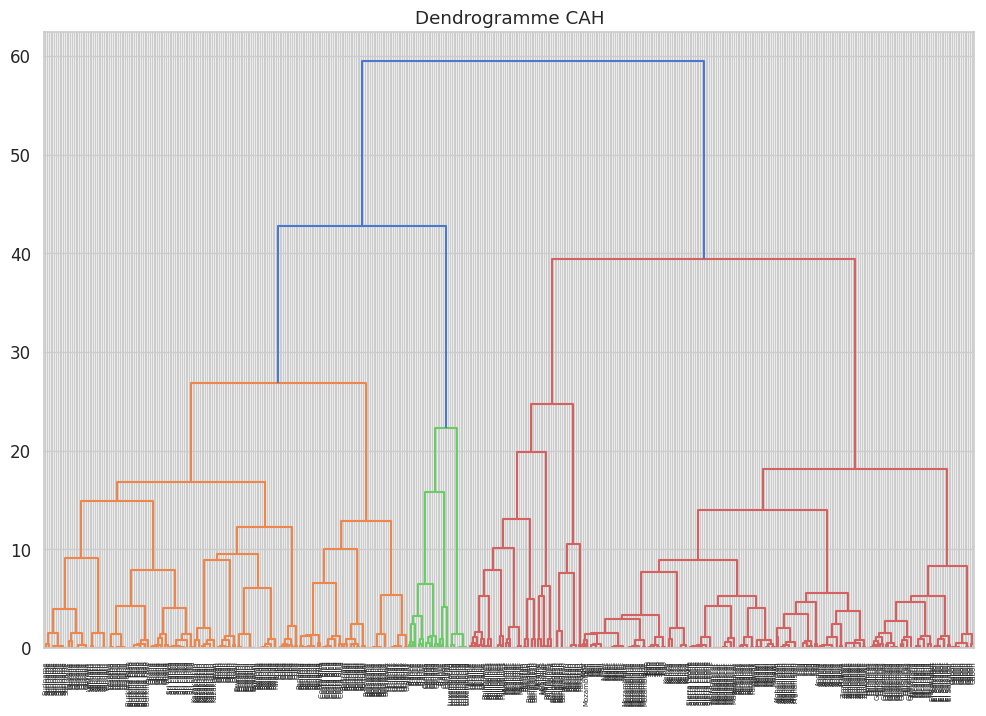

In [15]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,8))
dendrogram(linked, labels=Poulet['country'].values, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Dendrogramme CAH")
plt.show()

# Choix du nombre de clusters
k_cah = 4  # à ajuster selon le dendrogramme
Poulet['cluster_CAH'] = fcluster(linked, k_cah, criterion='maxclust')


## K-Means clustering

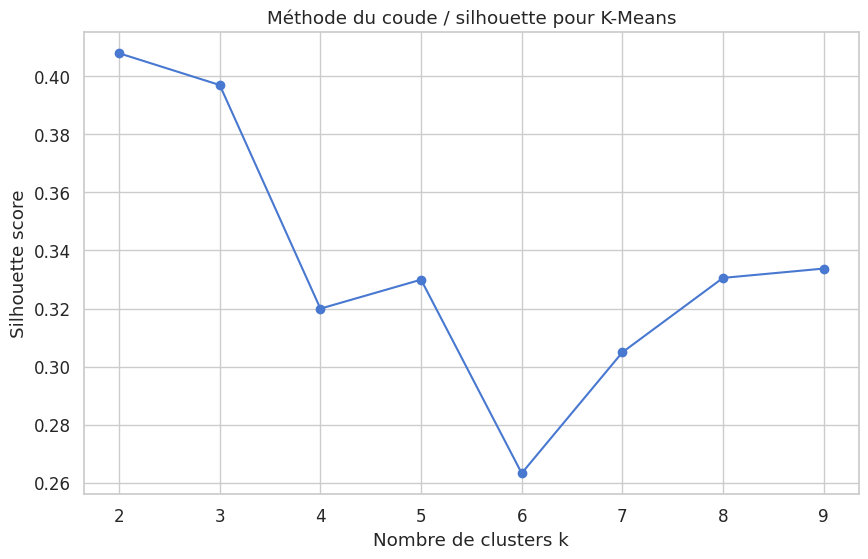

In [16]:
# Tester plusieurs k pour silhouette
sil_scores = []
K_range = range(2,10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=20, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot silhouette
plt.figure(figsize=(10,6))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette score")
plt.title("Méthode du coude / silhouette pour K-Means")
plt.show()

# K final
k_kmeans = K_range[np.argmax(sil_scores)]
kmeans = KMeans(n_clusters=k_kmeans, n_init=20, max_iter=300, random_state=42)
Poulet['cluster_KMeans'] = kmeans.fit_predict(X_scaled)


## Comparaison CAH vs KMeans

---



In [41]:
ari_score = adjusted_rand_score(Poulet['cluster_CAH'], Poulet['cluster_KMeans'])
print(f"Adjusted Rand Index entre CAH et K-Means : {ari_score:.2f}")


Adjusted Rand Index entre CAH et K-Means : 0.16


In [42]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

labels_cah = Poulet['cluster_CAH']
labels_km = Poulet['cluster_KMeans']

results = {
    "ARI (Adjusted Rand Index)": adjusted_rand_score(labels_cah, labels_km),
    "NMI (Normalized Mutual Info)": normalized_mutual_info_score(labels_cah, labels_km),
    "Homogeneity": homogeneity_score(labels_cah, labels_km),
    "Completeness": completeness_score(labels_cah, labels_km),
    "V-measure": v_measure_score(labels_cah, labels_km)
}

for k, v in results.items():
    print(f"{k} : {v:.3f}")


ARI (Adjusted Rand Index) : 0.158
NMI (Normalized Mutual Info) : 0.302
Homogeneity : 0.217
Completeness : 0.497
V-measure : 0.302


In [43]:

df_compare = pd.DataFrame.from_dict(
    results, orient='index', columns=['Score']
)

df_compare


,Score
ARI (Adjusted Rand Index),0.158046
NMI (Normalized Mutual Info),0.302100
Homogeneity,0.216982
Completeness,0.497103
V-measure,0.302100


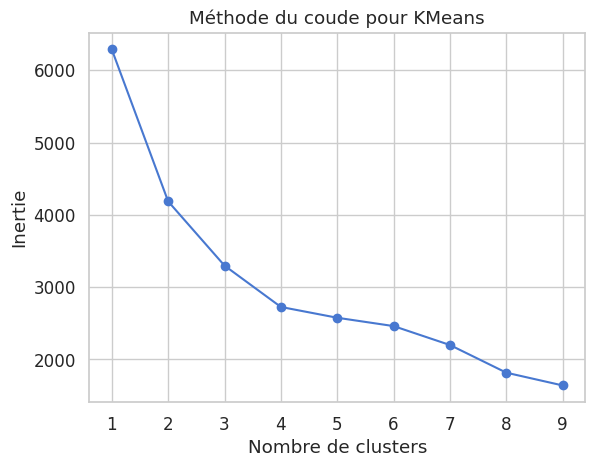

In [55]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude pour KMeans")
plt.show()


## Profilage des clusters

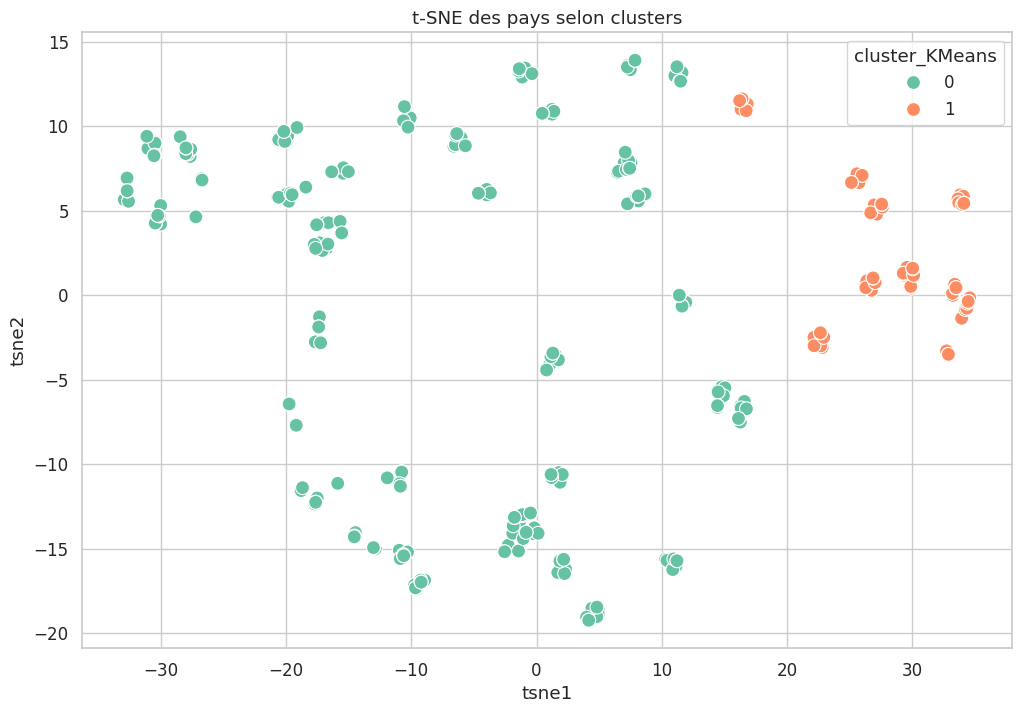

In [19]:
from sklearn.manifold import TSNE

# t-SNE pour visualisation alternative
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

Poulet['tsne1'] = X_tsne[:, 0]
Poulet['tsne2'] = X_tsne[:, 1]

plt.figure(figsize=(12,8))
sns.scatterplot(
    x='tsne1',
    y='tsne2',
    hue='cluster_KMeans',
    data=Poulet,
    palette='Set2',
    s=100
)
plt.title("t-SNE des pays selon clusters")
plt.show()


In [20]:
Poulet.head()

,Code Élément,Élément,Valeur_dali,Description du Symbole,Valeur_pop,viande_conso,country,production_tonnes,pib,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg,cluster_CAH,cluster_KMeans,tsne1,tsne2
0,5511,Production,28.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10,1,0,-32.635651,5.610148
1,5611,Importations - Quantité,29.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10,1,0,-32.637859,5.607607
2,5072,Variation de stock,0.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10,1,0,-32.917442,5.668153
3,5301,Disponibilité intérieure,57.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10,1,0,-32.573441,5.560715
4,5123,Pertes,2.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10,1,0,-32.908386,5.661559


## Sélection des 10 pays à cibler et 10 pays à éviter

In [21]:
from sklearn.preprocessing import MinMaxScaler

# Moyennes par pays pour éviter les doublons
Poulet_unique = Poulet.groupby('country').agg({
    'viande_conso': 'mean',
    'pib': 'mean',
    'Control_Corruption': 'mean',
    'Valeur_kg': 'sum'  # somme ou moyenne selon le sens
}).reset_index()

# Normalisation
scaler = MinMaxScaler()
Poulet_unique[['pib_norm', 'viande_conso_norm', 'Control_Corruption_norm']] = scaler.fit_transform(
    Poulet_unique[['pib', 'viande_conso', 'Control_Corruption']]
)

# Score composite = PIB + consommation - corruption
Poulet_unique['score_priorite'] = Poulet_unique['pib_norm'] + Poulet_unique['viande_conso_norm'] - Poulet_unique['Control_Corruption_norm']

# Top 10 pays prioritaires
top10 = Poulet_unique.sort_values(by='score_priorite', ascending=False).head(10)
print("Top 10 pays pour implantation :")
display(top10[['country', 'viande_conso', 'pib', 'Valeur_kg', 'Control_Corruption', 'score_priorite']])

# 10 pays à éviter
bottom10 = Poulet_unique.sort_values(by='score_priorite', ascending=True).head(10)
print("\n10 pays moins intéressants :")
display(bottom10[['country', 'viande_conso', 'pib', 'Valeur_kg', 'Control_Corruption', 'score_priorite']])


Top 10 pays pour implantation :


,country,viande_conso,pib,Valeur_kg,Control_Corruption,score_priorite
11,Gabon,37.110740,6921.733731,1.858341e+10,19.711538,0.799058
14,Guyana,40.581764,6178.665044,6.201777e+09,37.980770,0.682228
30,Panama,33.788193,15694.629745,3.696093e+10,31.730770,0.664705
25,Myanmar,32.020916,1272.822418,4.804428e+11,32.692307,0.478115
20,Luxembourg,18.802874,110193.213797,4.143371e+09,96.153847,0.448731
39,Ukraine,23.195496,2604.287598,3.559017e+11,21.153847,0.391860
26,Nicaragua,21.833525,2182.613810,4.469393e+10,18.269230,0.384793
5,Canada,38.889618,45129.628117,2.571247e+11,95.673080,0.369392
16,Iraq,14.833292,4759.284644,3.379751e+11,6.250000,0.361294
37,Suriname,31.697680,6049.521286,5.134465e+09,50.000000,0.325968



10 pays moins intéressants :


,country,viande_conso,pib,Valeur_kg,Control_Corruption,score_priorite
34,Rwanda,1.493453,758.300967,9.584770e+10,71.153847,-0.715955
3,Botswana,3.305942,7104.964011,1.764064e+10,77.403847,-0.679942
40,Uruguay,9.372448,19184.650262,2.749313e+10,88.461540,-0.536085
4,Burkina Faso,2.093819,709.091536,1.535459e+11,53.365383,-0.508498
19,Lesotho,6.228748,1069.366732,1.464074e+10,56.250000,-0.431801
9,Eswatini,6.650676,3853.991479,7.873636e+09,54.285713,-0.374463
12,Ghana,6.979396,2012.286626,2.038503e+11,48.076923,-0.315665
27,Niger,1.074957,521.804130,1.944215e+11,28.365385,-0.265161
35,Sierra Leone,3.953595,779.186008,6.739581e+10,33.173077,-0.242035
23,Mali,2.758344,924.057532,1.110746e+11,29.326923,-0.229302


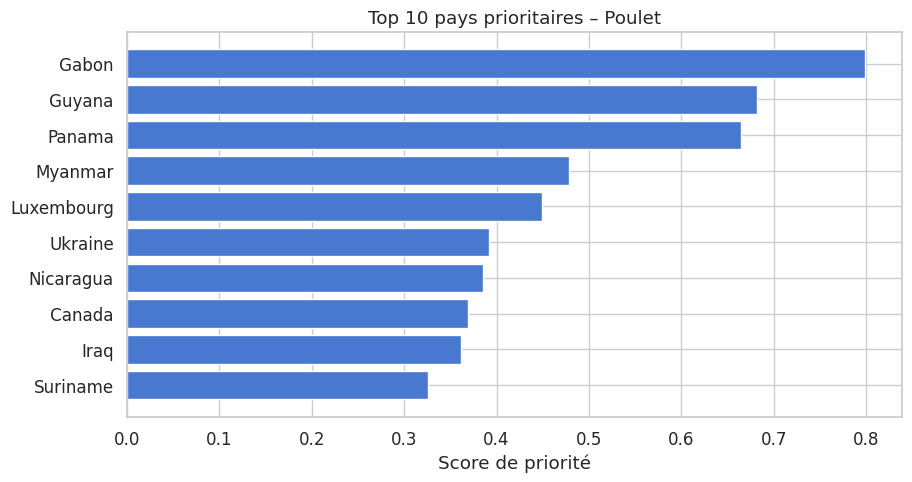

In [39]:

plt.figure(figsize=(10, 5))
plt.barh(top10['country'], top10['score_priorite'])
plt.xlabel("Score de priorité")
plt.title("Top 10 pays prioritaires – Poulet")
plt.gca().invert_yaxis()  # meilleur score en haut
plt.grid(True)
plt.show()


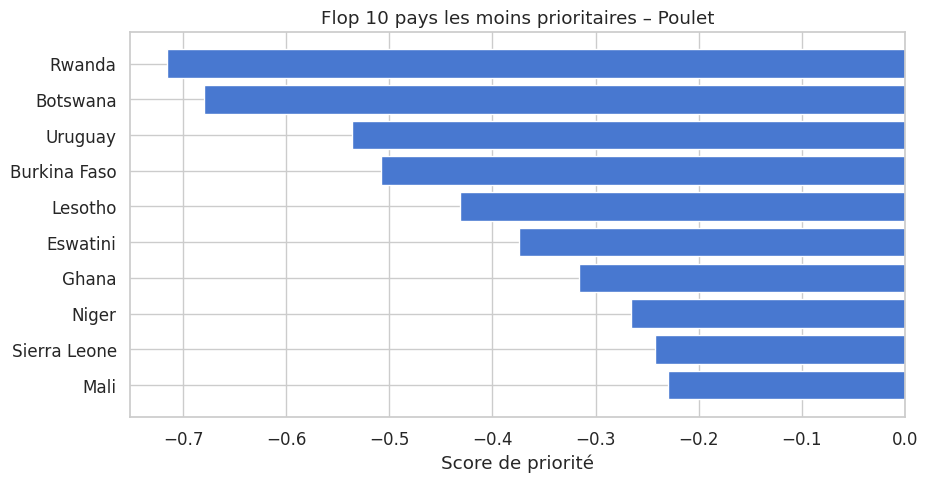

In [40]:
plt.figure(figsize=(10, 5))
plt.barh(bottom10['country'], bottom10['score_priorite'])
plt.xlabel("Score de priorité")
plt.title("Flop 10 pays les moins prioritaires – Poulet")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


## visualisation par cluster

In [22]:
# Calcul du cluster majoritaire pour chaque pays
Poulet_unique['cluster_KMeans'] = Poulet.groupby('country')['cluster_KMeans'].agg(lambda x: x.mode()[0]).values

# Vérifier
Poulet_unique[['country', 'cluster_KMeans']].head()


,country,cluster_KMeans
0,Afghanistan,0
1,Angola,0
2,Bangladesh,0
3,Botswana,1
4,Burkina Faso,0


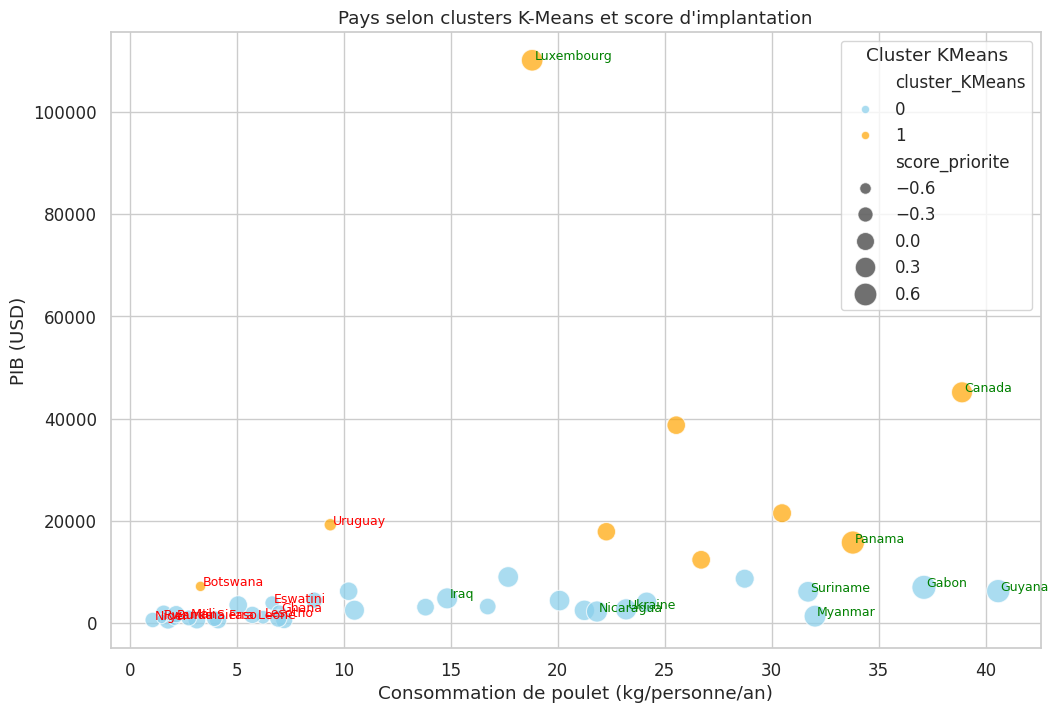

In [23]:
plt.figure(figsize=(12,8))

# Palette par cluster
cluster_colors = {0: 'skyblue', 1: 'orange'}

sns.scatterplot(
    data=Poulet_unique,
    x='viande_conso',
    y='pib',
    hue='cluster_KMeans',
    palette=cluster_colors,
    size='score_priorite',
    sizes=(50,300),
    alpha=0.7,
    legend='brief'
)

# Annoter Top 10
for i, row in top10.iterrows():
    plt.text(row['viande_conso']+0.1, row['pib']+0.1, row['country'], fontsize=9, color='green')

# Annoter Bottom 10
for i, row in bottom10.iterrows():
    plt.text(row['viande_conso']+0.1, row['pib']+0.1, row['country'], fontsize=9, color='red')

plt.xlabel("Consommation de poulet (kg/personne/an)")
plt.ylabel("PIB (USD)")
plt.title("Pays selon clusters K-Means et score d'implantation")
plt.grid(True)
plt.legend(title='Cluster KMeans')
plt.show()


In [24]:
pays_cibles = (
    Poulet_unique
    [Poulet_unique['cluster_KMeans'] == 0]
    .sort_values('score_priorite', ascending=False)
    [['country', 'score_priorite']]
)

pays_cibles.head(10)




,country,score_priorite
11,Gabon,0.799058
14,Guyana,0.682228
25,Myanmar,0.478115
39,Ukraine,0.391860
26,Nicaragua,0.384793
16,Iraq,0.361294
37,Suriname,0.325968
17,Kazakhstan,0.320553
13,Guatemala,0.307945
15,Honduras,0.293881


In [25]:
pays_cibles = (
    Poulet_unique
    [Poulet_unique['cluster_KMeans'] == 1]
    .sort_values('score_priorite', ascending=False)
    [['country', 'score_priorite']]
)

pays_cibles.head(10)


,country,score_priorite
30,Panama,0.664705
20,Luxembourg,0.448731
5,Canada,0.369392
33,Portugal,0.107338
6,Costa Rica,0.079538
10,France,0.061207
28,Oman,0.048823
40,Uruguay,-0.536085
3,Botswana,-0.679942


%ETHIDE DU COUDE


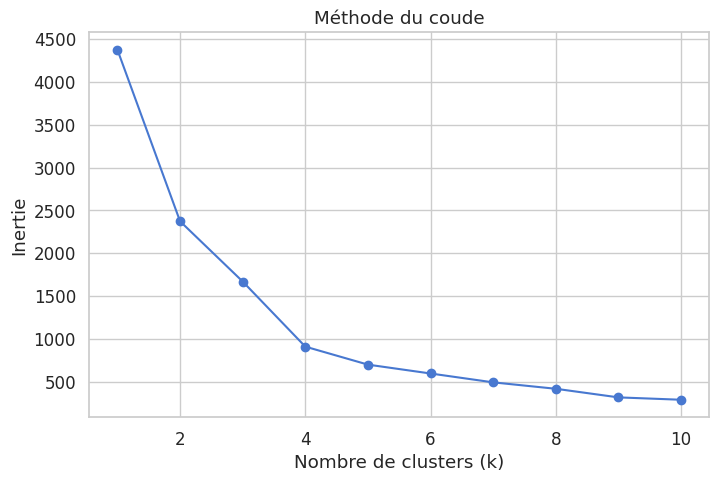

In [26]:
from sklearn.cluster import KMeans

# Données pour le clustering (ACP)
X_clust = scores[['PC1','PC2']]

# Méthode du coude
inertias = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_clust)
    inertias.append(km.inertia_)

# Graphique du coude
plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.grid(True)
plt.show()


In [27]:
k_values = [3, 5, 8]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    scores[f'cluster_{k}'] = km.fit_predict(X_clust)


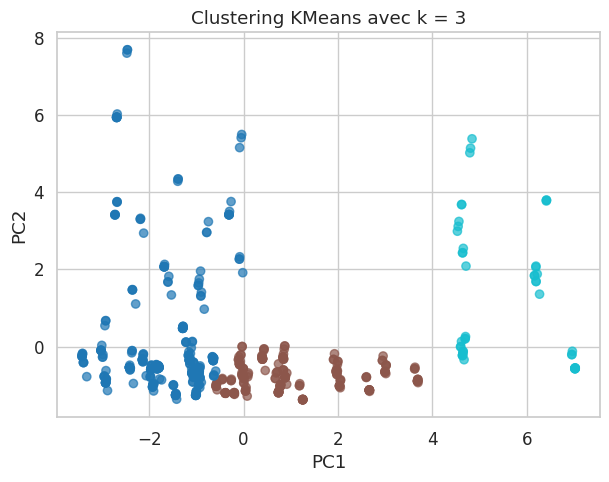

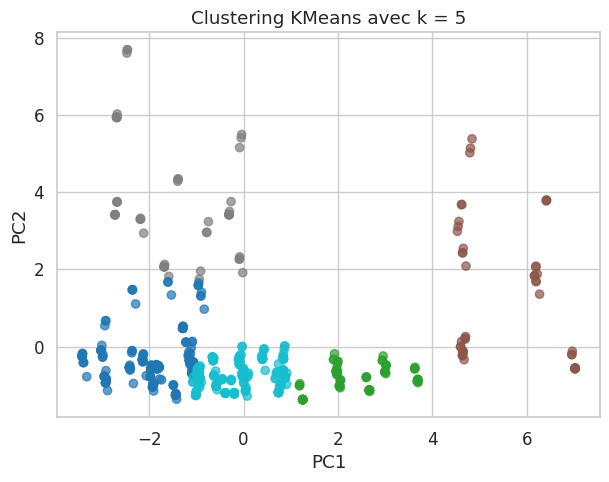

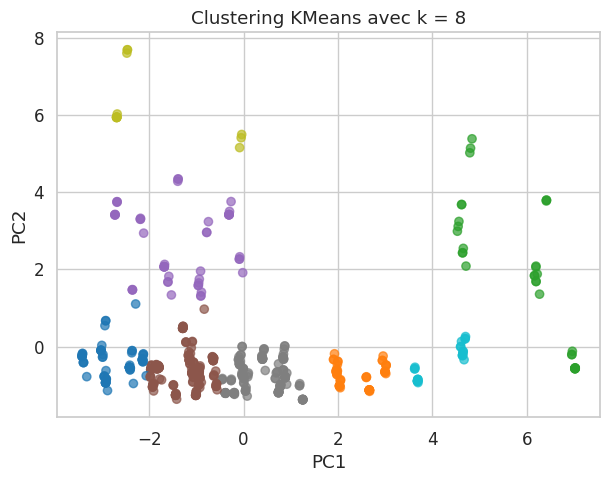

In [28]:
for k in k_values:
    plt.figure(figsize=(7,5))
    plt.scatter(
        scores['PC1'],
        scores['PC2'],
        c=scores[f'cluster_{k}'],
        cmap='tab10',
        alpha=0.7
    )
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Clustering KMeans avec k = {k}')
    plt.grid(True)
    plt.show()


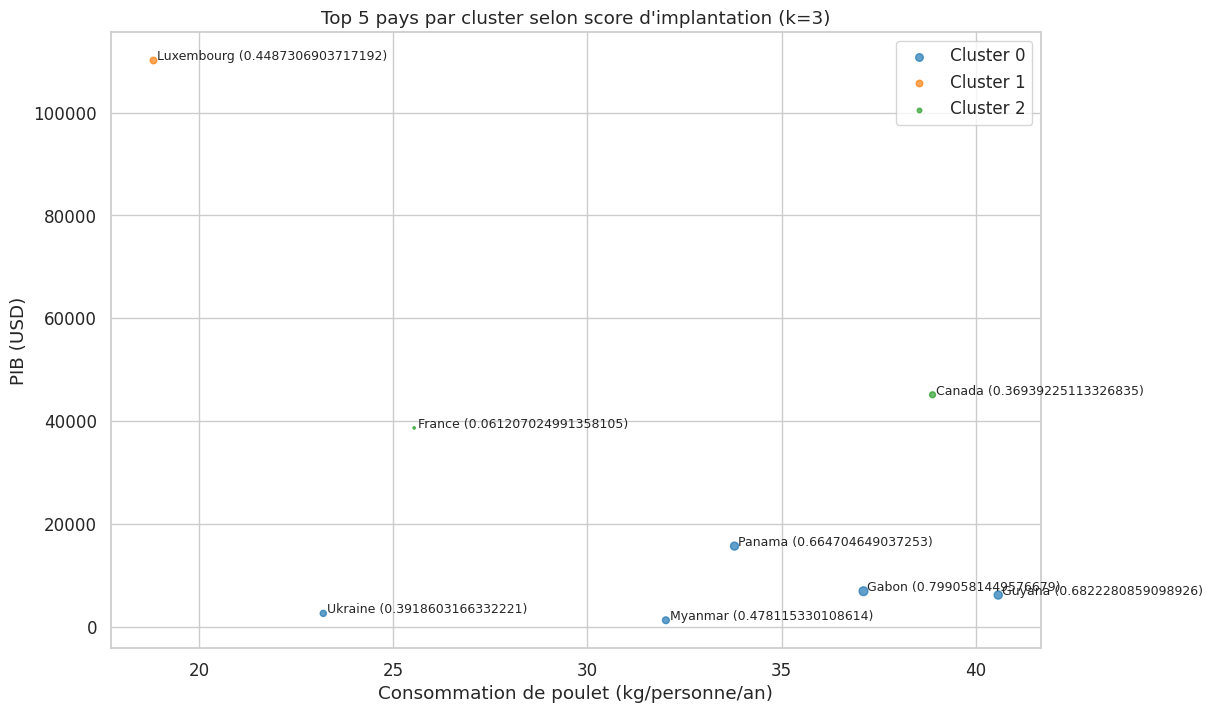

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Colonnes utilisées pour le clustering
X_clust = Poulet_unique[['viande_conso', 'pib']].copy()
top_n = 5  # top 5 pays par cluster

# Choisir le k à visualiser (ici 3 clusters comme exemple)
k = 3
km = KMeans(n_clusters=k, random_state=42)
Poulet_unique[f'cluster_{k}'] = km.fit_predict(X_clust)

# Palette de couleurs
cluster_colors = plt.cm.tab10.colors

plt.figure(figsize=(12,8))

for cluster in range(k):
    cluster_data = Poulet_unique[Poulet_unique[f'cluster_{k}'] == cluster]

    # Ne garder que les top_n pays par score_priorite
    cluster_top = cluster_data.sort_values('score_priorite', ascending=False).head(top_n)

    if cluster_top.empty:
        continue  # ignore cluster vide

    # Scatter
    plt.scatter(
        cluster_top['viande_conso'],
        cluster_top['pib'],
        s=cluster_top['score_priorite']*50,  # taille selon score
        color=cluster_colors[cluster % 10],
        alpha=0.7,
        label=f'Cluster {cluster}'
    )

    # Annoter les pays avec leur score
    for i, row in cluster_top.iterrows():
        plt.text(
            row['viande_conso'] + 0.1,
            row['pib'] + 0.1,
            f"{row['country']} ({row['score_priorite']})",
            fontsize=9
        )

plt.xlabel("Consommation de poulet (kg/personne/an)")
plt.ylabel("PIB (USD)")
plt.title(f"Top {top_n} pays par cluster selon score d'implantation (k={k})")
plt.grid(True)
plt.legend()
plt.show()


In [30]:
Poulet.columns

Index(['Code Élément', 'Élément', 'Valeur_dali', 'Description du Symbole',
       'Valeur_pop', 'viande_conso', 'country', 'production_tonnes', 'pib',
       'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
       'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg',
       'cluster_CAH', 'cluster_KMeans', 'tsne1', 'tsne2'],
      dtype='object')

In [31]:
Poulet['country'].nunique()


43

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)

    score = silhouette_score(X_clust, labels)
    print(f"Silhouette score pour k={k} : {score:.3f}")


Silhouette score pour k=3 : 0.760
Silhouette score pour k=5 : 0.648
Silhouette score pour k=8 : 0.548


In [33]:
labels = scores.loc[X_clust.index, f'cluster_{k}']
score = silhouette_score(X_clust, labels)
print(f"Silhouette score pour k={k} : {score:.3f}")


Silhouette score pour k=8 : -0.325


In [34]:
print(f"Silhouette score pour k={k} : {score:.2f}")

Silhouette score pour k=8 : -0.33


In [35]:
print(f"Silhouette score pour k={k} : {score:.1f}")

Silhouette score pour k=8 : -0.3


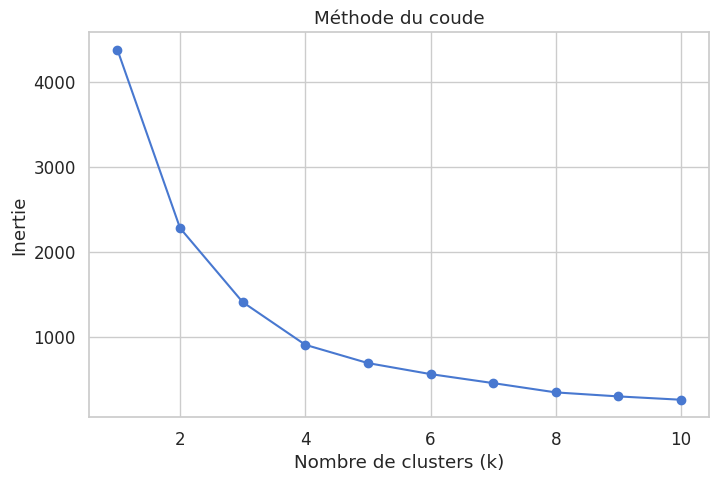

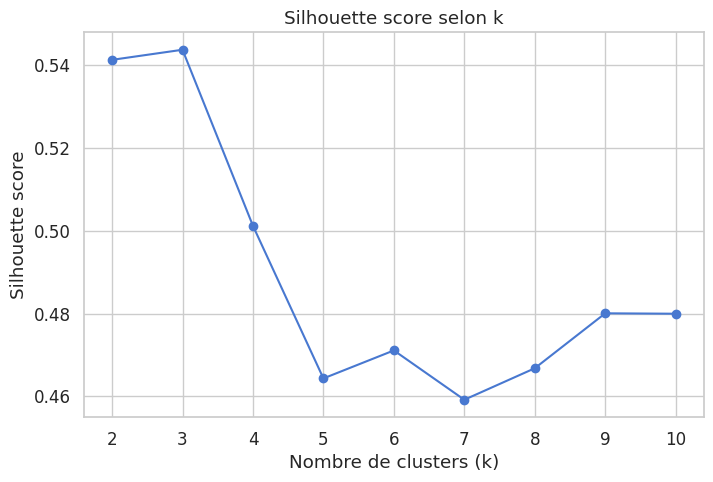

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Données pour le clustering (ACP)
X_clust = scores[['PC1', 'PC2']]

# Plages de k
K = range(1, 11)

inertias = []
silhouettes = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)

    inertias.append(km.inertia_)

    # Silhouette uniquement si k > 1
    if k > 1:
        silhouettes.append(silhouette_score(X_clust, labels))
    else:
        silhouettes.append(None)

# 🔹 Graphique du coude
plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.grid(True)
plt.show()

# 🔹 Graphique silhouette
plt.figure(figsize=(8,5))
plt.plot(K[1:], silhouettes[1:], marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score selon k')
plt.grid(True)
plt.show()


In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

X_clust = scores[['PC1', 'PC2']]
K = range(1, 11)

results = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)

    inertia = km.inertia_
    silhouette = silhouette_score(X_clust, labels) if k > 1 else None

    results.append({
        'k': k,
        'Inertie': inertia,
        'Silhouette': silhouette
    })

df_results = pd.DataFrame(results)
df_results


,k,Inertie,Silhouette
0,1,4377.390523,NaN
1,2,2279.819074,0.541341
2,3,1409.131139,0.543782
3,4,907.031248,0.501206
4,5,691.966733,0.464309
5,6,562.362992,0.471076
6,7,456.454592,0.459149
7,8,347.116797,0.466765
8,9,300.011898,0.480050
9,10,260.762165,0.479950
